# Credit Scoring Model

**CodeAlpha Internship - Task 1**

**Goal:** Predict if a person will default on a loan or not.

## 1. Import Libraries

In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix
)
import joblib

## 2. Load the Dataset



In [158]:
df = pd.read_csv('credit_risk_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 3. Exploratory Data Analysis

### 3.1 Basic Info

In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [160]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [161]:
# Check missing values
missing = df.isnull().sum()
print(missing[missing > 0])

person_emp_length     895
loan_int_rate        3116
dtype: int64


### 3.2 Target Distribution

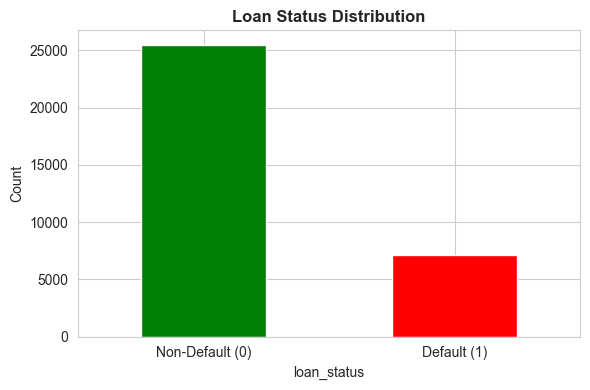

In [162]:
fig, ax = plt.subplots(figsize=(6, 4))
df['loan_status'].value_counts().plot(kind='bar', color=['green', 'red'], ax=ax)
ax.set_title('Loan Status Distribution', fontweight='bold')
ax.set_xticklabels(['Non-Default (0)', 'Default (1)'], rotation=0)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 3.3 Numerical Feature Distributions

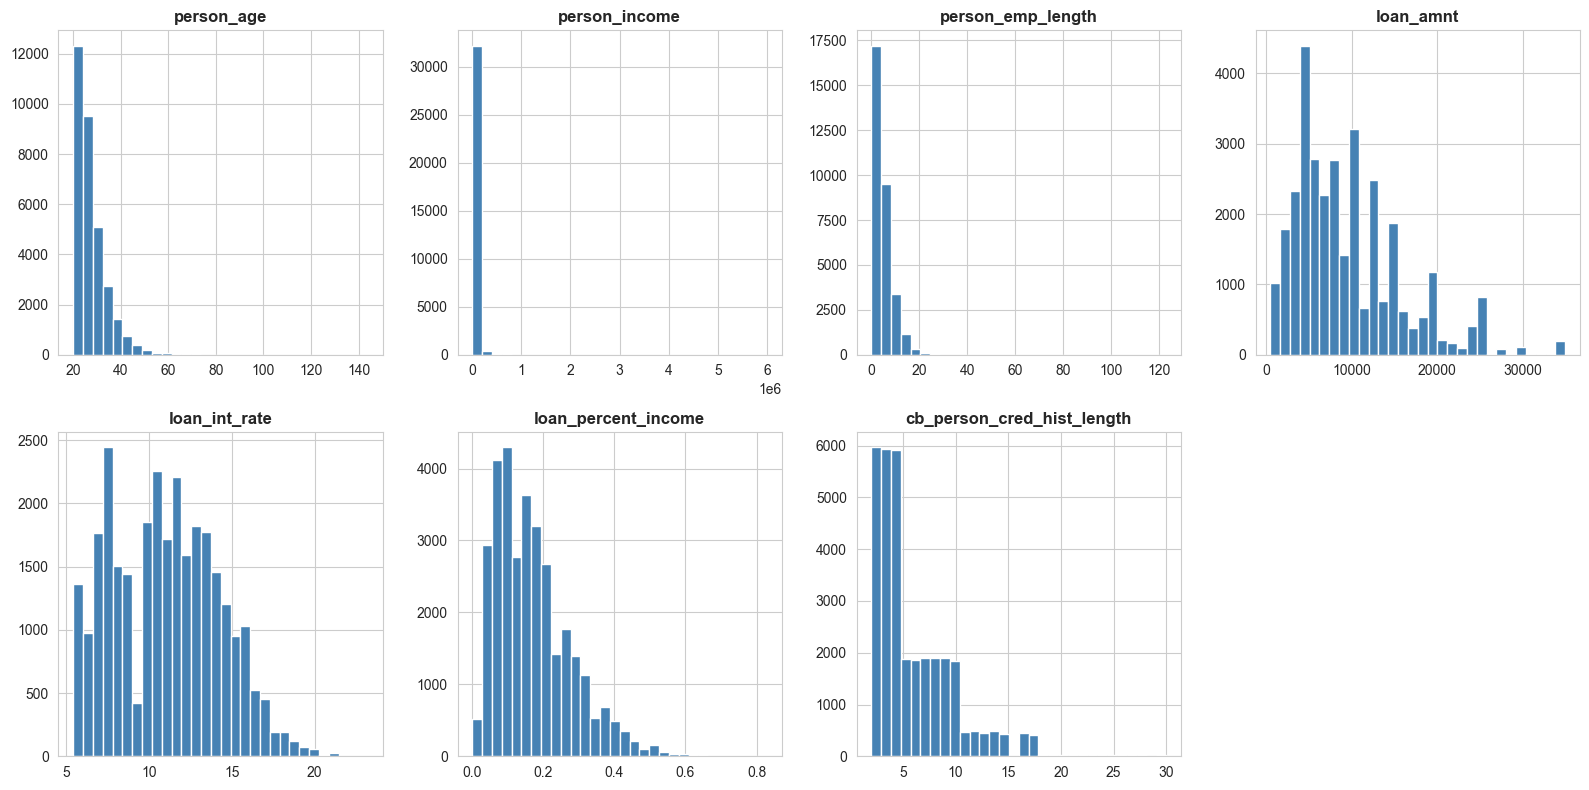

In [163]:
num_cols = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap

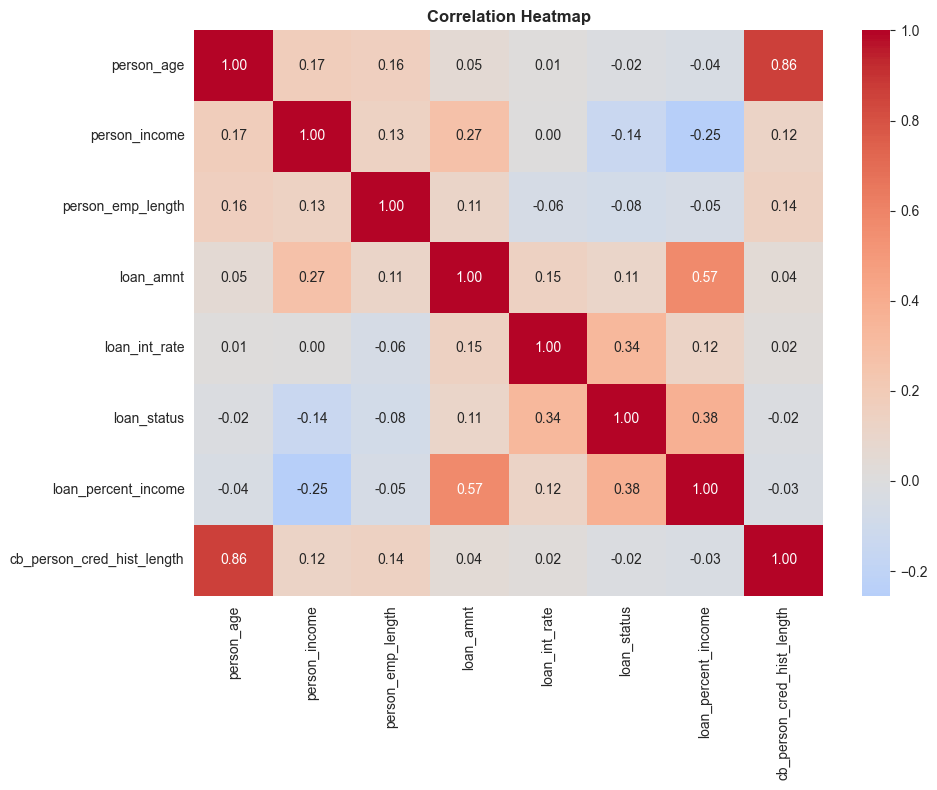

In [164]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

### 4.1 Handle Missing Values

In [165]:
# Fill missing numerical values with median
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)

print('Missing values after cleaning:')
print(df.isnull().sum())

Missing values after cleaning:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


### 4.2 Remove Outliers

In [166]:
df = df[df['person_age'] <= 80]
df = df[df['person_emp_length'] <= 50]
print(f'Shape after removing outliers: {df.shape}')

Shape after removing outliers: (32572, 12)


### 4.3 Encode Categorical Variables

In [167]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f'{col}: {list(le.classes_)}')

df.head()

Categorical columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
person_home_ownership: ['MORTGAGE', 'OTHER', 'OWN', 'RENT']
loan_intent: ['DEBTCONSOLIDATION', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL', 'PERSONAL', 'VENTURE']
loan_grade: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
cb_person_default_on_file: ['N', 'Y']


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,2,5.0,1,1,1000,11.14,0,0.10,0,2
2,25,9600,0,1.0,3,2,5500,12.87,1,0.57,0,3
3,23,65500,3,4.0,3,2,35000,15.23,1,0.53,0,2
4,24,54400,3,8.0,3,2,35000,14.27,1,0.55,1,4
5,21,9900,2,2.0,5,0,2500,7.14,1,0.25,0,2


## 5. Feature Engineering

In [168]:
# Create new features that capture risk signals
df['income_to_loan'] = df['person_income'] / (df['loan_amnt'] + 1)
df['age_emp_ratio'] = df['person_age'] / (df['person_emp_length'] + 1)
df['risk_score'] = (
    (df['loan_int_rate'] * df['loan_percent_income'])
    / (df['cb_person_cred_hist_length'] + 1)
)

print('New features added: income_to_loan, age_emp_ratio, risk_score')
print(f'Total features: {df.shape[1]}')

New features added: income_to_loan, age_emp_ratio, risk_score
Total features: 15


## 6. Split and Scale Data

In [169]:
# Separate features and target
X = df.drop('loan_status', axis=1)
y = df['loan_status']
feature_names = X.columns.tolist()

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train set: {X_train_scaled.shape[0]} samples')
print(f'Test set:  {X_test_scaled.shape[0]} samples')

Train set: 26057 samples
Test set:  6515 samples


## 7. Train Models

In [170]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
}

results = {}

for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    y_proba = clf.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'model': clf,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }

    print(f'{name}: F1={results[name]["f1"]:.4f}  ROC-AUC={results[name]["roc_auc"]:.4f}')

print('All models trained!')

Logistic Regression: F1=0.5619  ROC-AUC=0.8422
Decision Tree: F1=0.8035  ROC-AUC=0.9033
Random Forest: F1=0.7800  ROC-AUC=0.9107
All models trained!


## 8. Evaluate Models

### 8.1 Classification Reports

In [171]:
for name, res in results.items():
    print(f'--- {name} ---')
    print(classification_report(
        y_test, res['y_pred'],
        target_names=['Non-Default', 'Default']
    ))
    print()

--- Logistic Regression ---
              precision    recall  f1-score   support

 Non-Default       0.86      0.95      0.91      5093
     Default       0.73      0.45      0.56      1422

    accuracy                           0.85      6515
   macro avg       0.80      0.70      0.73      6515
weighted avg       0.83      0.85      0.83      6515


--- Decision Tree ---
              precision    recall  f1-score   support

 Non-Default       0.92      0.99      0.96      5093
     Default       0.97      0.68      0.80      1422

    accuracy                           0.93      6515
   macro avg       0.95      0.84      0.88      6515
weighted avg       0.93      0.93      0.92      6515


--- Random Forest ---
              precision    recall  f1-score   support

 Non-Default       0.91      0.99      0.95      5093
     Default       0.97      0.65      0.78      1422

    accuracy                           0.92      6515
   macro avg       0.94      0.82      0.87      6515


### 8.2 Comparison Table

In [172]:
comparison = pd.DataFrame({
    name: {
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1-Score': r['f1'],
        'ROC-AUC': r['roc_auc']
    }
    for name, r in results.items()
}).T.round(4)

comparison

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.8451,0.7344,0.4550,0.5619,0.8422
Decision Tree,0.9269,0.9730,0.6842,0.8035,0.9033
Random Forest,0.9196,0.9677,0.6533,0.7800,0.9107


### 8.3 Confusion Matrices

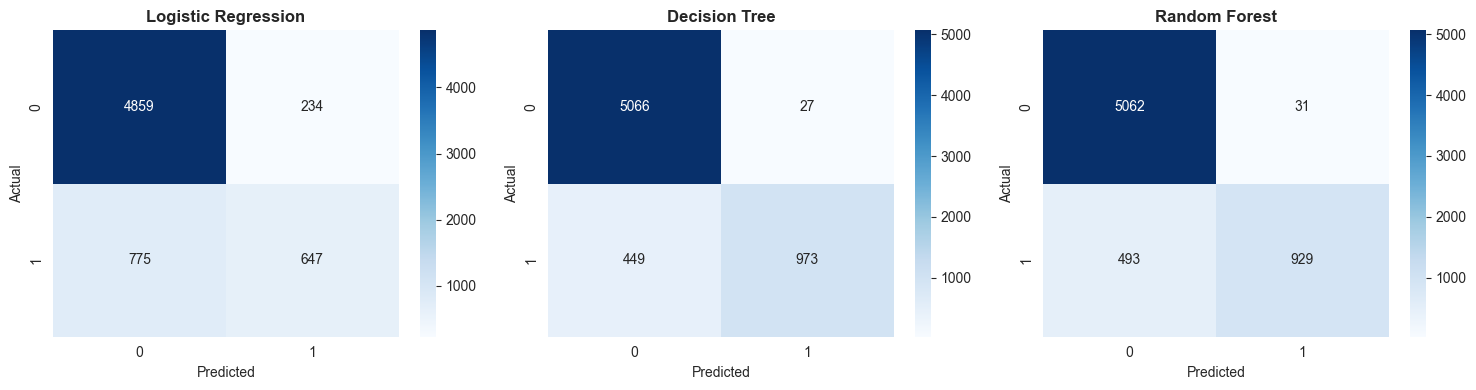

In [173]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 8.4 ROC Curves

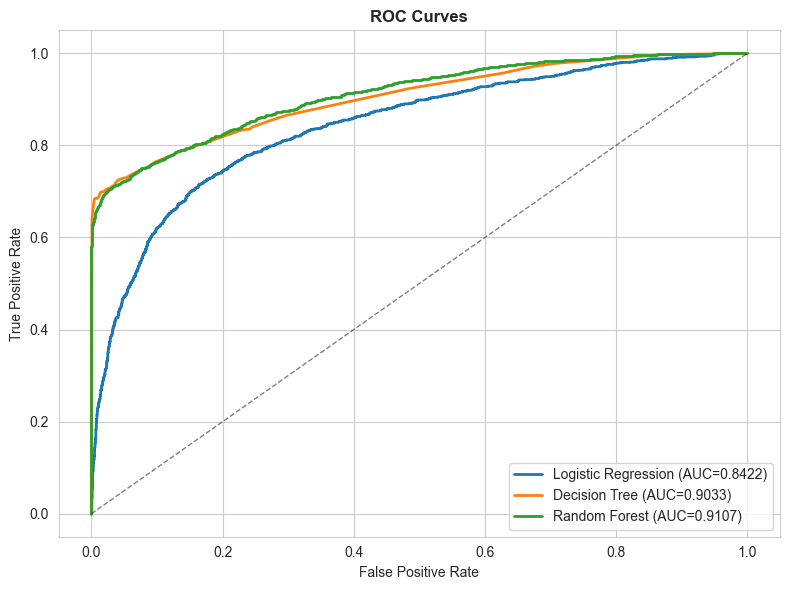

In [174]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={res['roc_auc']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 8.5 Metrics Comparison Chart

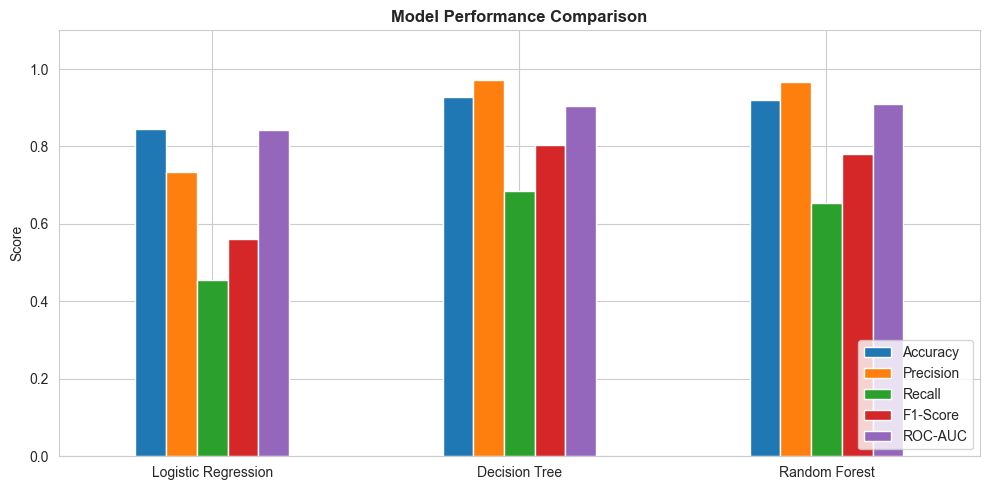

In [175]:
comparison.plot(kind='bar', figsize=(10, 5), edgecolor='white')
plt.title('Model Performance Comparison', fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 8.6 Feature Importance (Random Forest)

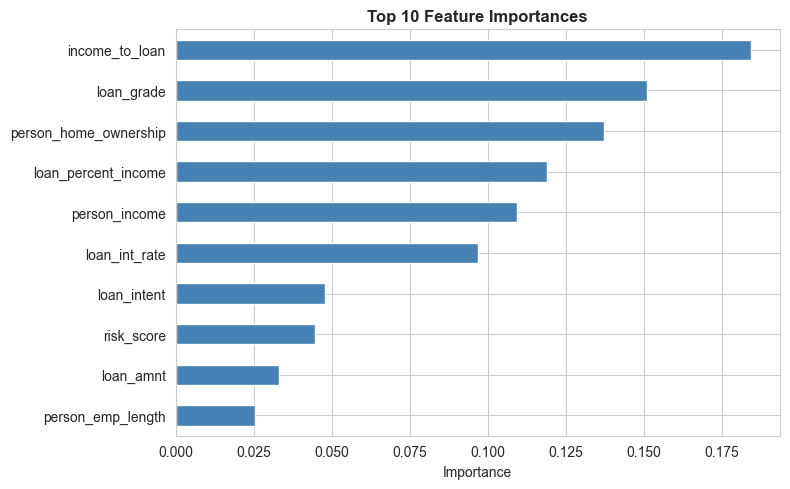

In [176]:
rf = results['Random Forest']['model']
importance = pd.Series(rf.feature_importances_, index=feature_names)
importance = importance.sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind='barh', color='steelblue', ax=ax, edgecolor='white')
ax.set_title('Top 10 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 9. Save the Best Model

In [177]:
# Select best model by F1-Score
best_name = max(results, key=lambda k: results[k]['f1'])
best_model = results[best_name]['model']

print(f'Best Model: {best_name}')
print(f'F1-Score:   {results[best_name]["f1"]:.4f}')
print(f'ROC-AUC:    {results[best_name]["roc_auc"]:.4f}')

# Save for deployment (files saved to project root)
joblib.dump(best_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_names, 'features.pkl')
joblib.dump(label_encoders, 'encoders.pkl')
print('Model and preprocessing objects saved successfully!')

Best Model: Decision Tree
F1-Score:   0.8035
ROC-AUC:    0.9033
Model and preprocessing objects saved successfully!
